In [8]:
import wfdb
import pandas as pd
import matplotlib.pyplot as plt

## Load Metadata

In [9]:
metadata = pd.read_csv('brugada-syndrome/metadata.csv')

In [10]:
print(metadata.head())
print(f"Total subjects: {len(metadata)}")
print(f"Brugada patients: {(metadata['brugada'] > 0).sum()}")
print(f"Healthy subjects: {(metadata['brugada'] == 0).sum()}")

   patient_id  basal_pattern  sudden_death  brugada
0      188981              1             0        1
1      251972              0             0        0
2      265715              0             0        0
3      267628              0             0        0
4      267630              0             0        1
Total subjects: 363
Brugada patients: 76
Healthy subjects: 287


## Initial Visualization

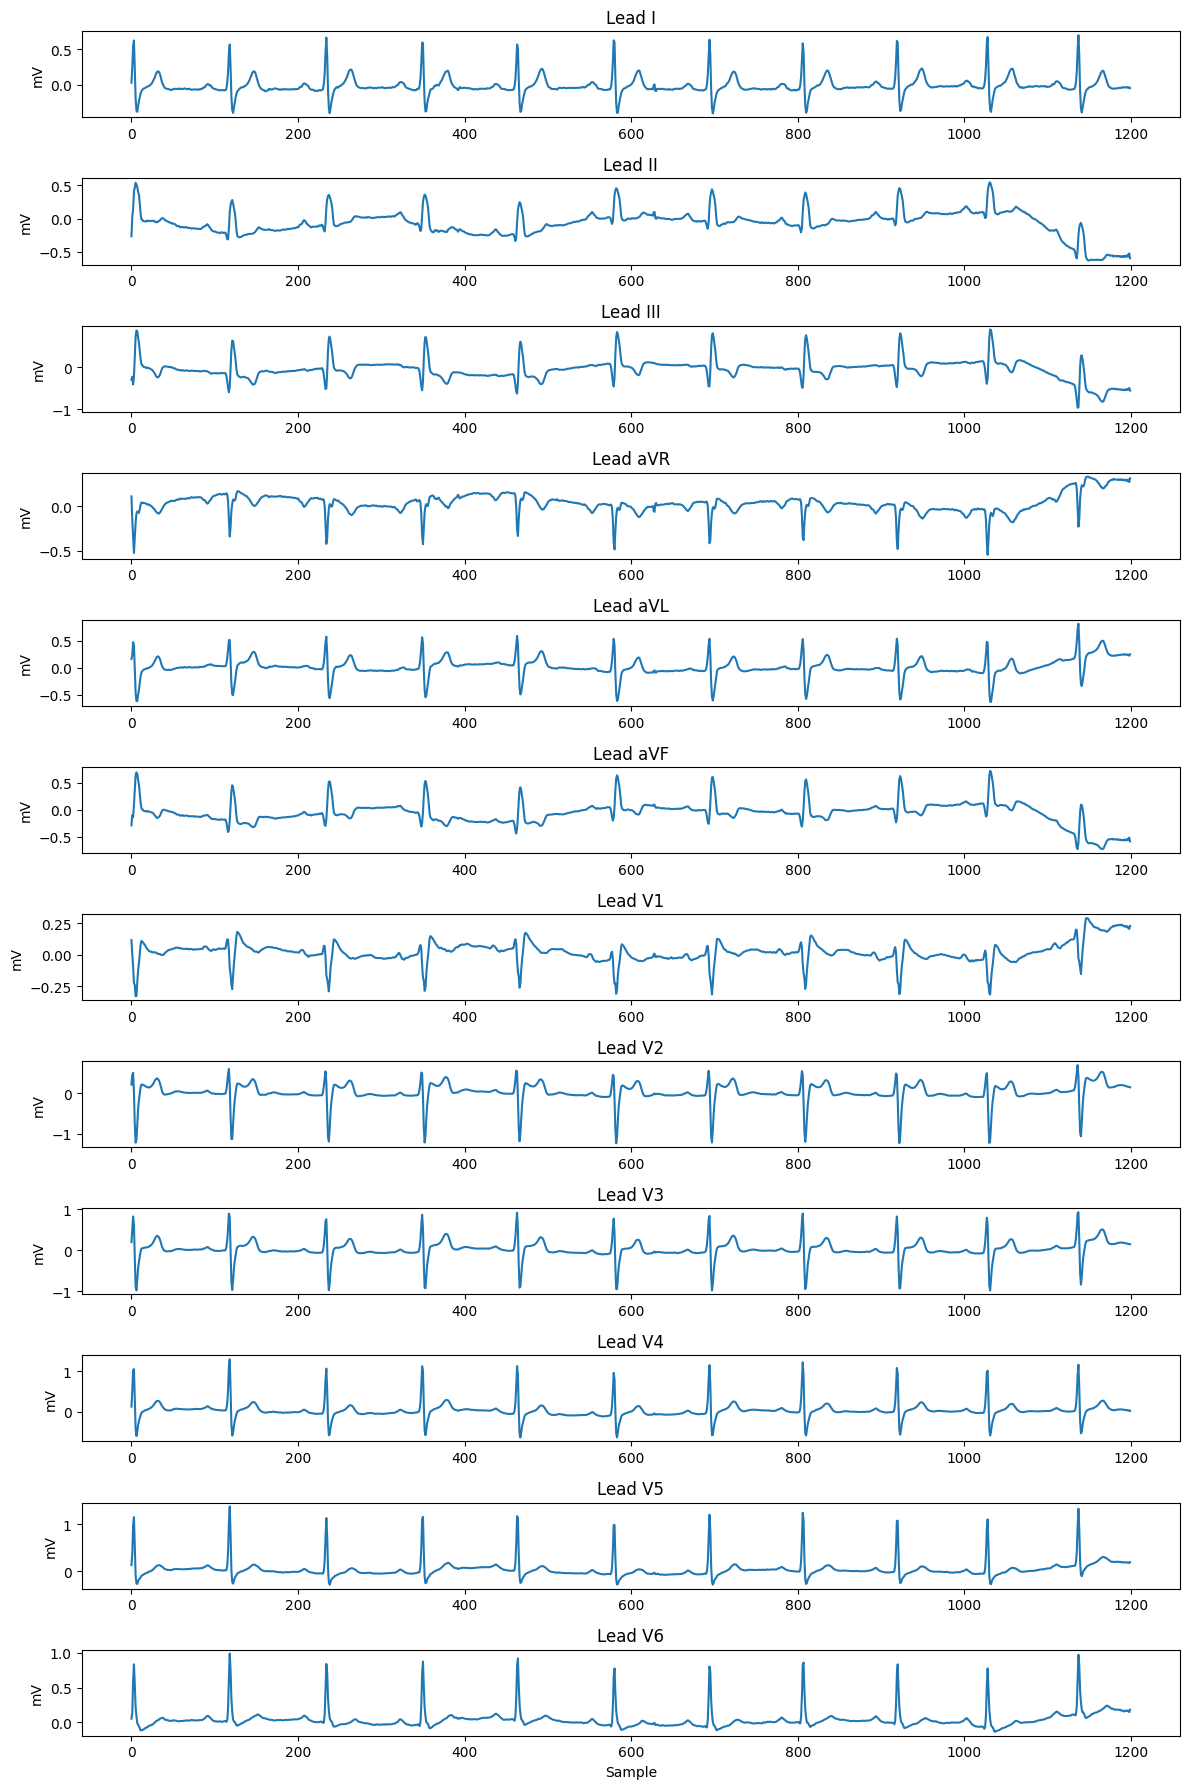

In [11]:
patient_id = '188981'
record = wfdb.rdrecord(f'brugada-syndrome/files/{patient_id}/{patient_id}')

signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs

num_leads = len(lead_names)

plt.figure(figsize=(12, 18))

for i in range(num_leads):
    plt.subplot(num_leads, 1, i + 1)
    plt.plot(signals[:, i])
    plt.title(f'Lead {lead_names[i]}')
    plt.ylabel('mV')

plt.xlabel('Sample')
plt.tight_layout()
plt.show()

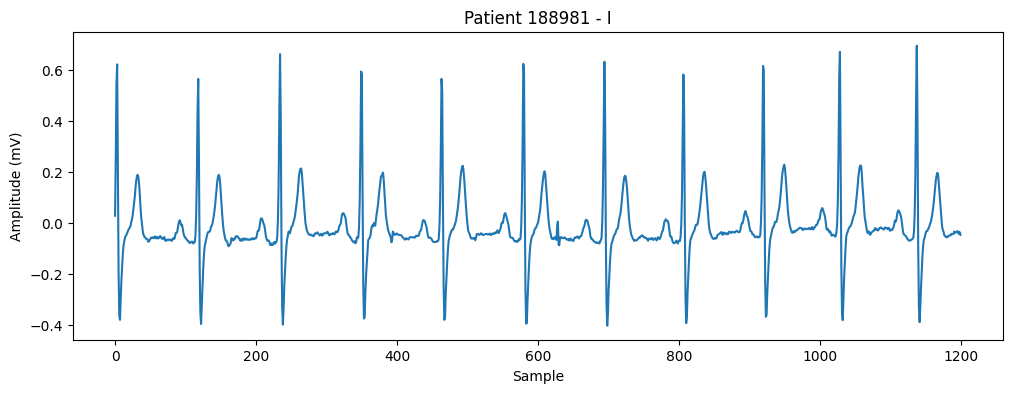

In [17]:
import matplotlib.pyplot as plt

# Read a single patient's ECG
patient_id = '188981'
record = wfdb.rdrecord(f'brugada-syndrome/files/{patient_id}/{patient_id}')

# Access the signal data
signals = record.p_signal       # Signal array (samples × leads)
lead_names = record.sig_name    # Lead names (I, II, III, aVR, aVL, aVF, V1–V6)
sampling_freq = record.fs       # Sampling frequency (100 Hz)

# Plot a specific lead
plt.figure(figsize=(12, 4))
plt.plot(signals[:, 0])  # Plot first lead (Lead I)
plt.title(f'Patient {patient_id} - {lead_names[0]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

## Filtering

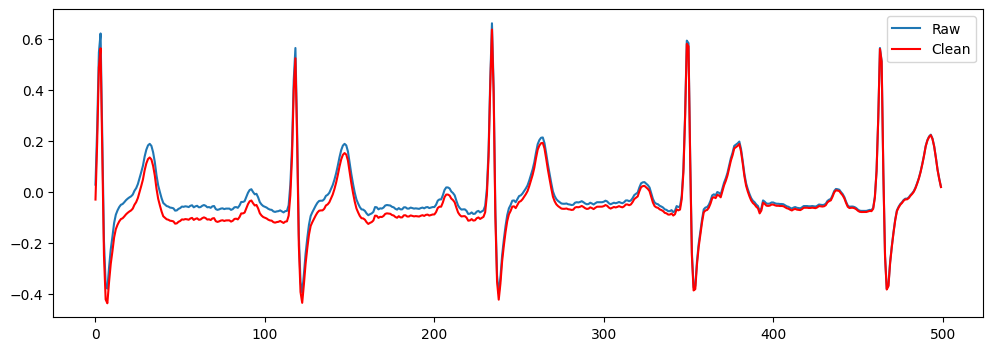

In [ ]:
from scipy import signal

def signal_cleaning(raw_data):
    b, a = signal.butter(3, 0.05, btype='highpass', fs=100)
    return signal.filtfilt(b, a, raw_data)

clean_signal = signal_cleaning(signals[:, 0])


plt.figure(figsize=(12, 4))
plt.plot(signals[0:500, 0], label='Raw')
plt.plot(clean_signal[0:500], label='Clean', color='red')
plt.legend()
plt.show()

## Normalization

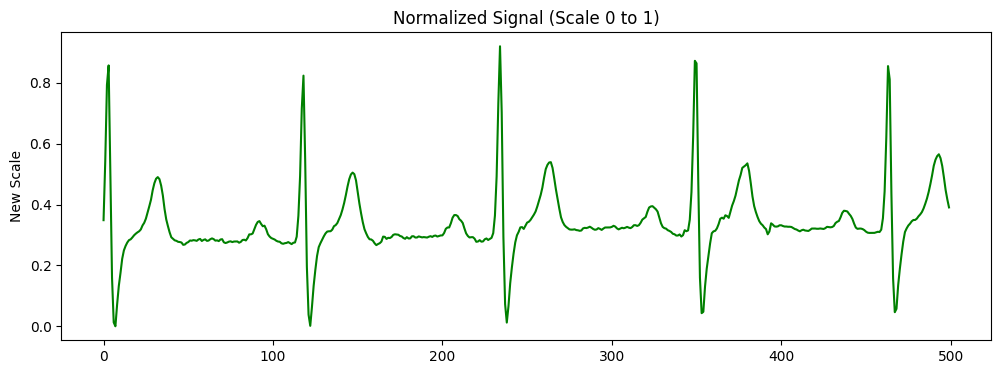

In [20]:
# Normalize
normal_signal = (clean_signal - clean_signal.min()) / (clean_signal.max() - clean_signal.min())


plt.figure(figsize=(12, 4))
plt.plot(normal_signal[0:500], color='green')
plt.title('Normalized Signal (Scale 0 to 1)')
plt.ylabel('New Scale')
plt.show()

## Peak Detection

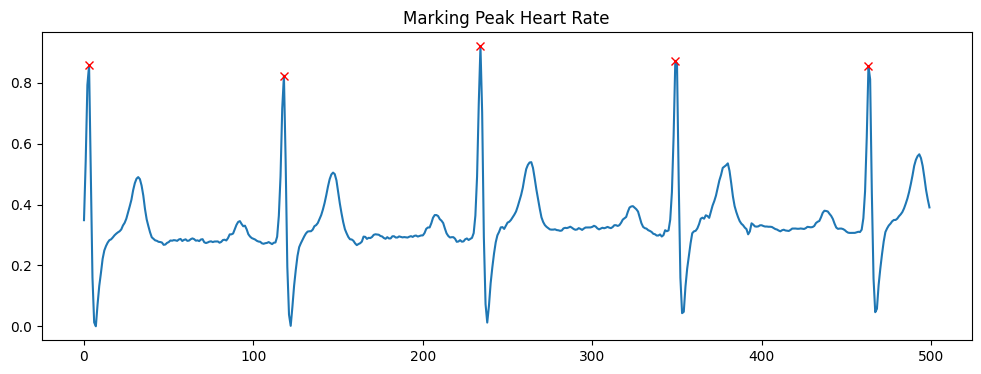

Peak position found: [  3 118 234 349 463]


In [23]:
from scipy.signal import find_peaks

# Finding Peak R
peaks, _ = find_peaks(normal_signal, distance=50, height=0.4)

plt.figure(figsize=(12, 4))
plt.plot(normal_signal[0:500])
plt.plot(peaks[peaks < 500], normal_signal[peaks[peaks < 500]], "x", color='red')
plt.title('Marking Peak Heart Rate')
plt.show()

print(f"Peak position found: {peaks[:5]}")

## Windowing

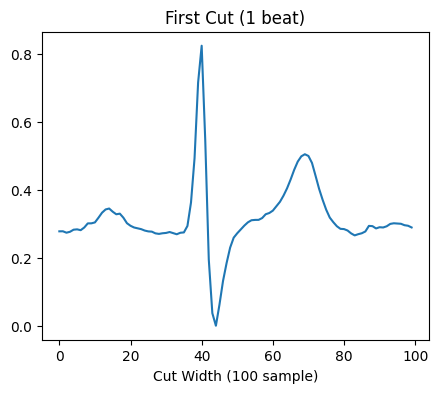

In [ ]:
import numpy as np

heartbeat_collection = []
left_width = 40
right_width = 60

# Cutting
for p in peaks:
    if p > left_width and p < (len(normal_signal) - right_width):
        snippet = normal_signal[p - left_width : p + right_width]
        heartbeat_collection.append(snippet)

# Convert to Array
heartbeat_collection = np.array(heartbeat_collection)


plt.figure(figsize=(5, 4))
plt.plot(heartbeat_collection[0])
plt.title('First Cut (1 beat)')
plt.xlabel('Cut Width (100 sample)')
plt.show()